In [1]:
import os
import duckdb
import pandas as pd
import plotly.express as px
from dotenv import load_dotenv
from typing import Literal, Optional
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate

In [2]:
# 1. Initialize DuckDB and load cleaned datasets
con = duckdb.connect(database=':memory:')
# Load cleaned data (use .parquet or .csv depending on what you exported)
fact_txn = pd.read_csv('cleaned_data/fact_transactions.csv')
fact_cbk = pd.read_csv('cleaned_data/fact_chargebacks.csv')
dim_merchants = pd.read_csv('cleaned_data/dim_merchants.csv')
dim_customers = pd.read_csv('cleaned_data/dim_customers.csv')
# Register tables in DuckDB so SQL can query them directly
con.register('fact_transactions', fact_txn)
con.register('fact_chargebacks', fact_cbk)
con.register('dim_merchants', dim_merchants)
con.register('dim_customers', dim_customers)

In [3]:
class AgentChartResponse(BaseModel):
    sql_query: str = Field(
        description="A valid, executable DuckDB SQL query to fetch data for the user's question."
    )
    chart_type: Literal["bar", "line", "scatter", "table"] = Field(
        description="The best chart type: 'line' for time trends/dates, 'bar' for categorical rankings/comparisons, 'scatter' for relationships/distributions, or 'table' for raw tabular lookups."
    )
    x_axis: str = Field(description="Exact column name from SQL query result for the X-axis.")
    y_axis: str = Field(description="Exact column name from SQL query result for the Y-axis.")
    chart_title: str = Field(description="A clean, professional title for the graph.")
    executive_summary: str = Field(
        description="A 2-3 sentence executive business takeaway summarizing the insights."
    )

In [4]:
# System prompt providing database schema context
SYSTEM_PROMPT = """You are an elite FinTech Data Analyst Agent for a National Payments Authority.
Your task is to answer business questions about UPI transactions, merchant risk, and fraud chargebacks.

You have access to 4 tables in a SQL database:

1. `fact_transactions`:
   - txn_id (VARCHAR), user_id (VARCHAR), merchant_id (VARCHAR), amount (FLOAT)
   - txn_timestamp (TIMESTAMP), status_clean (VARCHAR: 'SUCCESS', 'FAILED', 'PENDING')
   - merchant_category_final (VARCHAR: 'Grocery', 'Hotel / Lodging', 'Telecom', 'Transportation', etc.)
   - has_kyc_match (BOOLEAN), has_merchant_match (BOOLEAN), utr_missing_or_invalid (BOOLEAN)

2. `fact_chargebacks`:
   - complaint_id (VARCHAR), txn_id (VARCHAR), user_id (VARCHAR), merchant_id (VARCHAR)
   - disputed_amount_clean (FLOAT), report_delay_days (FLOAT)
   - resolution_status_clean (VARCHAR), severity_clean (VARCHAR: 'CRITICAL', 'HIGH', 'MEDIUM', 'LOW')
   - reason_code_clean (VARCHAR: 'Duplicate Debit', 'Service Not Delivered', 'Account Takeover', etc.)
   - channel_clean (VARCHAR: 'IVR', 'App', 'Call Center', etc.)
   - txn_amount (FLOAT), txn_status (VARCHAR)

3. `dim_merchants`:
   - merchant_id (VARCHAR), merchant_name (VARCHAR), business_type_clean (VARCHAR)
   - city_clean (VARCHAR), state (VARCHAR), merchant_status_clean (VARCHAR: 'ACTIVE', 'INACTIVE', 'SUSPENDED')
   - declared_avg_ticket_size_clean (FLOAT), settlement_account_on_file (BOOLEAN)

4. `dim_customers`:
   - user_id (VARCHAR), full_name (VARCHAR), city_clean (VARCHAR), state (VARCHAR)
   - monthly_income_clean (FLOAT), kyc_status_clean (VARCHAR: 'VERIFIED', 'PENDING', 'REJECTED')
   - risk_segment_clean (VARCHAR: 'LOW', 'MEDIUM', 'HIGH')

Guidelines:
- Return only valid SQL queries compatible with DuckDB.
- Choose 'line' for date/time trends, 'bar' for categorical rankings or comparisons, and 'scatter' for numeric correlations/distributions.
- Provide a clear, actionable executive summary interpreting the numbers.
"""

def create_agent(api_key: str):
    llm = ChatGoogleGenerativeAI(
        model="gemini-flash-latest",
        google_api_key=api_key,
        temperature=0.1
    )
    
    # Bind structured output to Pydantic schema
    structured_llm = llm.with_structured_output(AgentChartResponse)
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", SYSTEM_PROMPT),
        ("human", "{question}")
    ])
    
    return prompt | structured_llm

In [5]:
def run_query(agent, question: str):
    print(f"\nAnalyzing Question: '{question}'...")
    
    # 1. Ask the LangChain agent
    response: AgentChartResponse = agent.invoke({"question": question})
    
    print(f"Generated SQL: {response.sql_query}")
    print(f"Chosen Chart: {response.chart_type.upper()}")
    
    # 2. Execute SQL query on DuckDB
    try:
        result_df = con.execute(response.sql_query).df()
    except Exception as e:
        return None, f"SQL Execution Error: {e}"
        
    if result_df.empty:
        return None, "No data found for this query."
    
    # 3. Render the Plotly chart dynamically based on agent's selection
    fig = None
    if response.chart_type == "line":
        fig = px.line(result_df, x=response.x_axis, y=response.y_axis, title=response.chart_title)
    elif response.chart_type == "bar":
        fig = px.bar(result_df, x=response.x_axis, y=response.y_axis, title=response.chart_title)
    elif response.chart_type == "scatter":
        fig = px.scatter(result_df, x=response.x_axis, y=response.y_axis, title=response.chart_title)
    else:
        # Table / raw view fallback
        fig = None

    return fig, response.executive_summary, result_df


Analyzing Question: 'Which merchant category has the highest chargeback count?'...


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Generated SQL: SELECT COALESCE(ft.merchant_category_final, 'Unknown') AS merchant_category, COUNT(fc.complaint_id) AS total_chargebacks, ROUND(SUM(fc.disputed_amount_clean), 2) AS total_disputed_amount FROM fact_chargebacks fc JOIN fact_transactions ft ON fc.txn_id = ft.txn_id GROUP BY ft.merchant_category_final ORDER BY total_chargebacks DESC
Chosen Chart: BAR

Executive Summary:
 Identifies the merchant categories driving the highest volume of consumer dispute claims and total disputed value. Risk teams should prioritize merchant underwriting criteria, enforce enhanced authentication, and review dispute resolution workflows for top-ranking dispute categories.


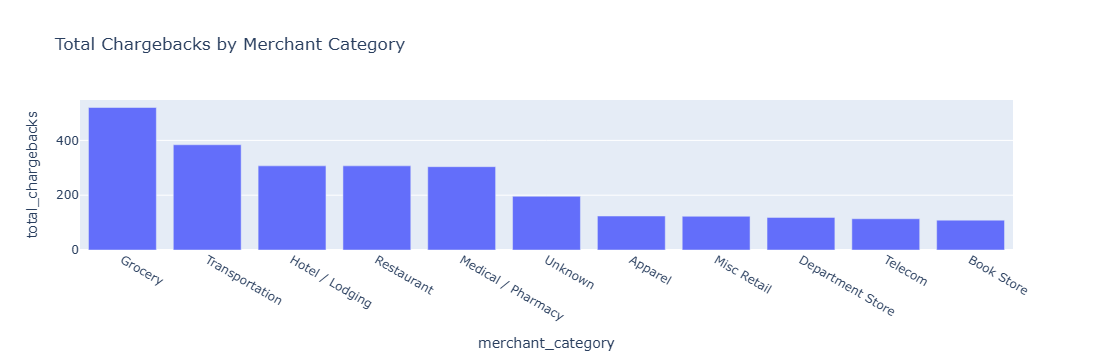


Analyzing Question: 'Show daily transaction volume trend.'...
Generated SQL: SELECT CAST(txn_timestamp AS DATE) AS txn_date, COUNT(txn_id) AS transaction_count, ROUND(SUM(amount), 2) AS total_volume FROM fact_transactions GROUP BY CAST(txn_timestamp AS DATE) ORDER BY txn_date ASC
Chosen Chart: LINE

Executive Summary:
 Daily transaction throughput illustrates overall network adoption and activity patterns across the analyzed timeframe. Monitoring day-over-day volume variations allows the payments authority to identify peak operational loads, anomaly dips, and capacity scaling requirements.


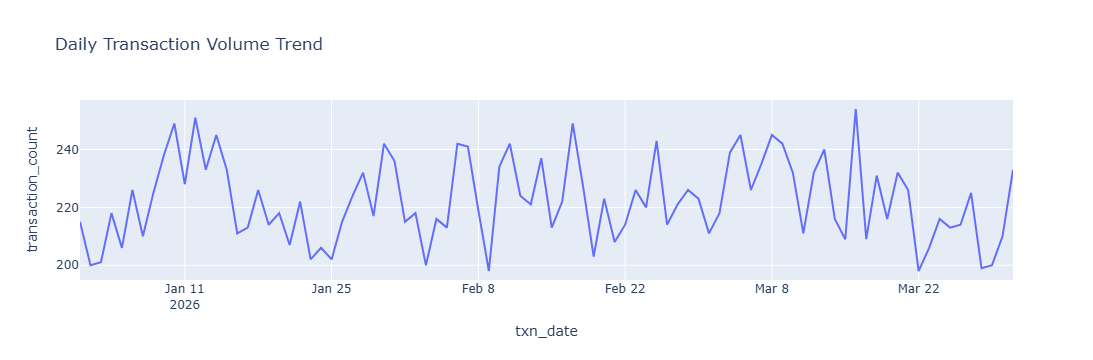

In [6]:
load_dotenv()
if __name__ == "__main__":
    # 2. Retrieve the key from .env
    GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
    
    # 3. Helpful safety check
    if not GEMINI_API_KEY:
        raise ValueError(
            "GEMINI_API_KEY is missing! "
            "Please create a .env file with: GEMINI_API_KEY=your_key_here"
        )
    
    # 4. Initialize the agent
    agent = create_agent(GEMINI_API_KEY)
    
    # Test 1: Category vs Chargeback (Official Challenge Query!)
    test_q = "Which merchant category has the highest chargeback count?"
    fig, summary, df = run_query(agent, test_q)
    print("\nExecutive Summary:\n", summary)
    if fig:
        fig.show()
        
    # Test 2: Trend Query (Should automatically choose a 'line' chart)
    test_q2 = "Show daily transaction volume trend."
    fig, summary, df = run_query(agent, test_q2)
    print("\nExecutive Summary:\n", summary)
    if fig:
        fig.show()